# QuantStrata Machine Learning Pipeline — TensorFlow Tutorial

This comprehensive tutorial demonstrates the QuantStrata ML framework, a production-grade TensorFlow-native pipeline for quantitative finance applications.

## What You'll Learn

| Section | Topics |
|---------|--------|
| **1. Data Preparation** | TFDataset, normalization, train/val/test splits, tf.data.Dataset |
| **2. Model Architecture** | MLPPricer, PricingModel base class, custom architectures |
| **3. Training** | Trainer class, TrainingConfig, callbacks, early stopping |
| **4. Evaluation** | Evaluator, metrics (MSE, MAE, R², MAPE), visualization |
| **5. Inference** | SavedModel export, loading, Predictor class |
| **6. Advanced Topics** | Greeks via autodiff, uncertainty estimation, ensembles |

---

## Prerequisites

Install dependencies from the project root:

```bash
pip install -r requirements.txt
# or at least: pip install tensorflow numpy pandas matplotlib scipy
```

The tutorial uses **TensorFlow 2.x** and the QuantStrata ML module.

**Important:** Run the **first code cell (Setup and imports)** before running any other cell. It adds the project root to `sys.path` so that `src.m_learning` imports work.

In [1]:
# Setup and imports — run this cell first before any other cells
import sys
from pathlib import Path

# Find project root (directory containing src/m_learning)
def _find_project_root():
    path = Path.cwd()
    for _ in range(6):
        if (path / "src" / "m_learning").exists():
            return path
        if path.parent == path:
            break
        path = path.parent
    # Fallback: assume notebook is in docs/tutorials/m_learning
    return Path.cwd().parents[2]

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Set style for better plots (fallback if seaborn style missing)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"Project root: {project_root}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Project root: /Users/joesstevens/PycharmProjects/QuantStrata
TensorFlow version: 2.20.0
GPU available: False


---

# 1. Data Preparation

The ML pipeline starts with data preparation. The `TFDataset` class provides a unified interface for:

- **Feature/target storage** with NumPy arrays
- **Normalization** (z-score or min-max scaling)
- **Train/val/test splitting**
- **Conversion to `tf.data.Dataset`** for efficient training

## 1.1 Generating Synthetic Data

For this tutorial, we'll generate synthetic option pricing data. The `create_pricing_dataset` function:

1. Samples random option parameters (spot, strike, vol, rate, expiry, type)
2. Computes Black-Scholes prices as targets
3. Returns a `TFDataset` with features and targets

In [2]:
from src.m_learning.data import create_pricing_dataset, TFDataset

# Generate 20,000 samples
dataset = create_pricing_dataset(
    n_samples=20000,
    spot_range=(80, 120),      # Underlying price range
    strike_range=(80, 120),    # Strike price range
    vol_range=(0.10, 0.50),    # Volatility range (10% - 50%)
    rate_range=(0.01, 0.10),   # Risk-free rate (1% - 10%)
    expiry_range=(0.1, 2.0),   # Time to expiry (0.1 - 2 years)
    seed=42,
)

print(f"Dataset: {dataset}")
print(f"\nFeature names: {dataset.feature_names}")
print(f"Target names: {dataset.target_names}")
print(f"\nMetadata: {dataset.metadata}")

Dataset: TFDataset(n_samples=20000, n_features=6, n_targets=1)

Feature names: ['spot', 'strike', 'volatility', 'rate', 'time_to_expiry', 'is_call']
Target names: ['price']

Metadata: {'n_samples': 20000, 'spot_range': (80, 120), 'strike_range': (80, 120), 'vol_range': (0.1, 0.5), 'rate_range': (0.01, 0.1), 'expiry_range': (0.1, 2.0), 'seed': 42, 'pricing_method': 'black_scholes'}


In [3]:
# Examine the data
features_df = pd.DataFrame(dataset.features, columns=dataset.feature_names)
features_df['price'] = dataset.targets.flatten()

print("Data Statistics:")
print(features_df.describe().round(3))

Data Statistics:
            spot     strike  volatility       rate  time_to_expiry    is_call  \
count  20000.000  20000.000   20000.000  20000.000       20000.000  20000.000   
mean      99.974     99.975       0.300      0.055           1.047      0.508   
std       11.540     11.515       0.116      0.026           0.550      0.500   
min       80.000     80.000       0.100      0.010           0.100      0.000   
25%       89.995     90.018       0.200      0.033           0.564      0.000   
50%       99.957    100.042       0.300      0.055           1.053      1.000   
75%      109.966    109.845       0.401      0.077           1.526      1.000   
max      119.997    119.996       0.500      0.100           2.000      1.000   

           price  
count  20000.000  
mean      13.447  
std       10.243  
min        0.000  
25%        4.986  
50%       11.615  
75%       20.000  
max       53.238  


## 1.2 Visualizing the Data

Let's explore the distribution of features and their relationship to option prices.

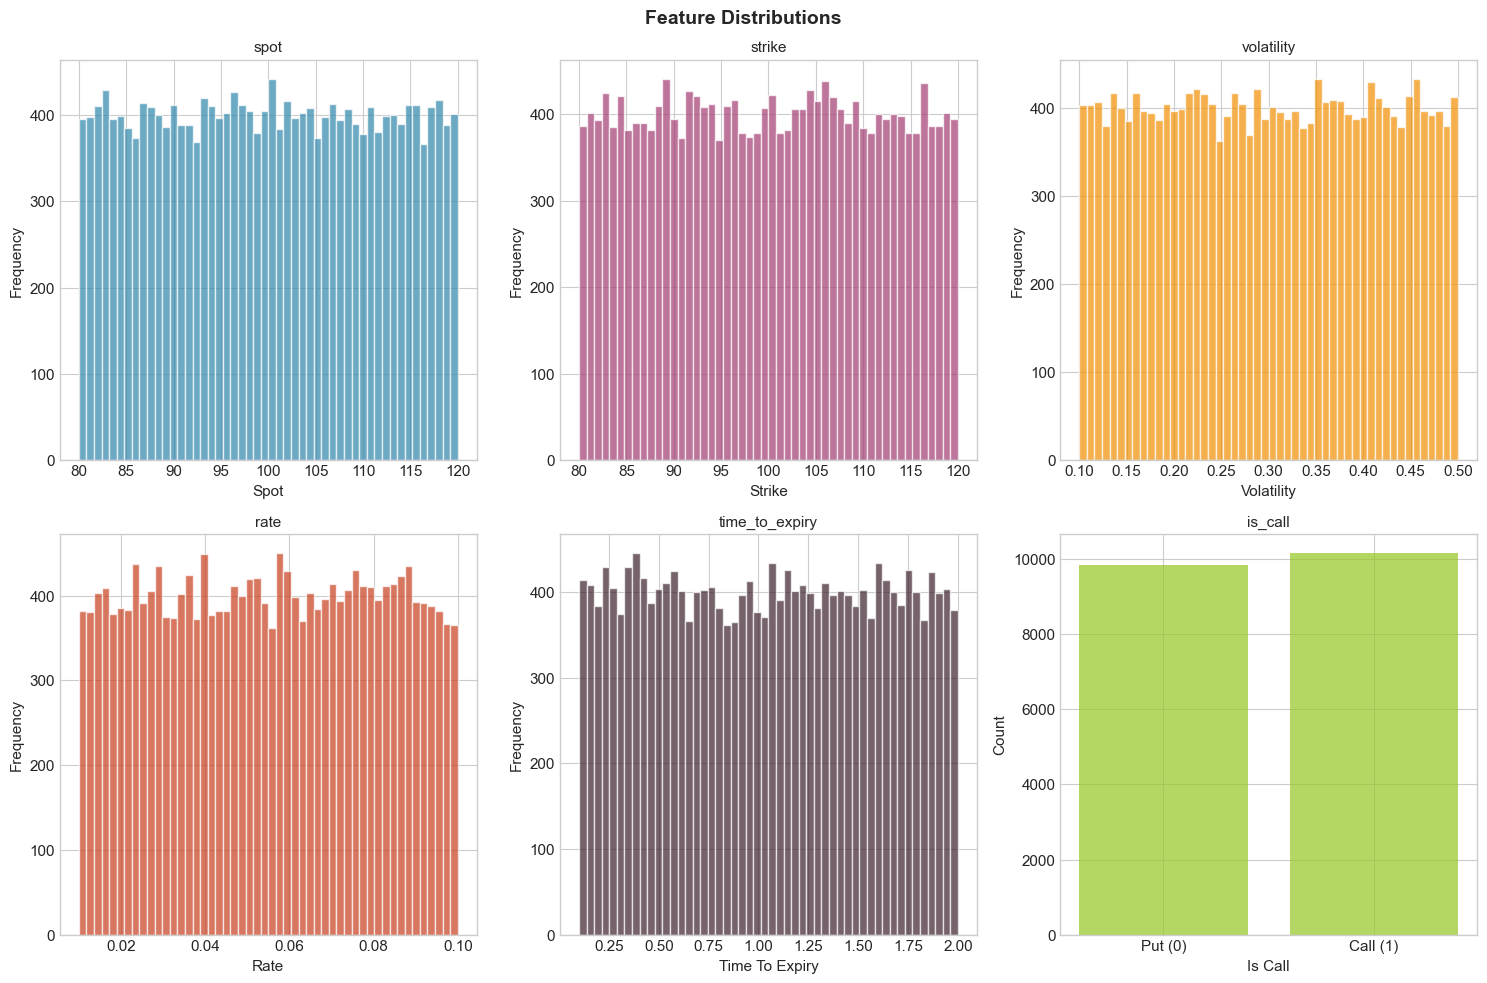

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

feature_names = ['spot', 'strike', 'volatility', 'rate', 'time_to_expiry', 'is_call']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95C623']

for i, (ax, name, color) in enumerate(zip(axes.flat, feature_names, colors)):
    if name == 'is_call':
        # Bar chart for categorical
        counts = features_df[name].value_counts().sort_index()
        ax.bar(['Put (0)', 'Call (1)'], counts.values, color=color, alpha=0.7)
        ax.set_ylabel('Count')
    else:
        # Histogram for continuous
        ax.hist(features_df[name], bins=50, color=color, alpha=0.7, edgecolor='white')
        ax.set_ylabel('Frequency')
    
    ax.set_xlabel(name.replace('_', ' ').title())
    ax.set_title(f'{name}', fontsize=11)

plt.tight_layout()
plt.show()

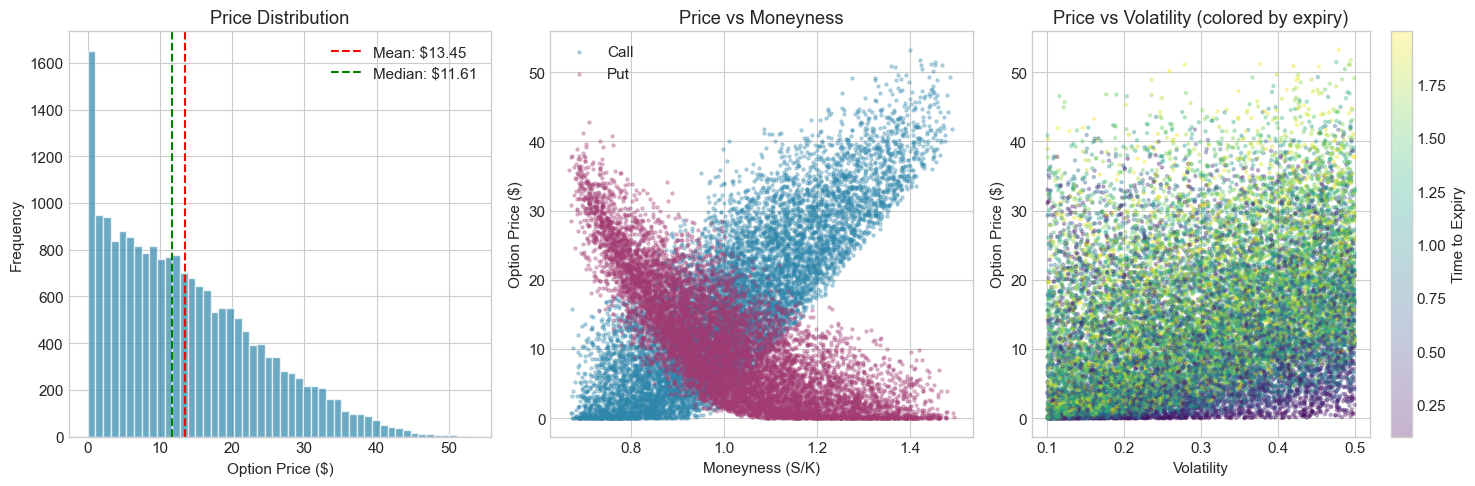

In [5]:
# Price distribution and relationship to key features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Price distribution
ax = axes[0]
ax.hist(features_df['price'], bins=50, color='#2E86AB', alpha=0.7, edgecolor='white')
ax.axvline(features_df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${features_df["price"].mean():.2f}')
ax.axvline(features_df['price'].median(), color='green', linestyle='--', label=f'Median: ${features_df["price"].median():.2f}')
ax.set_xlabel('Option Price ($)')
ax.set_ylabel('Frequency')
ax.set_title('Price Distribution')
ax.legend()

# 2. Price vs Moneyness
ax = axes[1]
moneyness = features_df['spot'] / features_df['strike']
calls = features_df['is_call'] > 0.5
ax.scatter(moneyness[calls], features_df['price'][calls], alpha=0.3, s=5, label='Call', color='#2E86AB')
ax.scatter(moneyness[~calls], features_df['price'][~calls], alpha=0.3, s=5, label='Put', color='#A23B72')
ax.set_xlabel('Moneyness (S/K)')
ax.set_ylabel('Option Price ($)')
ax.set_title('Price vs Moneyness')
ax.legend()

# 3. Price vs Volatility
ax = axes[2]
scatter = ax.scatter(features_df['volatility'], features_df['price'], 
                     c=features_df['time_to_expiry'], alpha=0.3, s=5, cmap='viridis')
plt.colorbar(scatter, ax=ax, label='Time to Expiry')
ax.set_xlabel('Volatility')
ax.set_ylabel('Option Price ($)')
ax.set_title('Price vs Volatility (colored by expiry)')

plt.tight_layout()
plt.show()

## 1.3 Normalization

Neural networks train better with normalized data. The `TFDataset` class provides:

- **Z-score normalization**: `(x - mean) / std` → mean=0, std=1
- **Min-max normalization**: `(x - min) / (max - min)` → range [0, 1]

The normalization statistics are saved and can be used to denormalize predictions later.

In [6]:
# Normalize features and targets
dataset.normalize_features(method='zscore')
dataset.normalize_targets(method='zscore')

print("Normalization Statistics:")
print(f"\nFeature means: {dataset.feature_stats.mean.round(3)}")
print(f"Feature stds:  {dataset.feature_stats.std.round(3)}")
print(f"\nTarget mean: {dataset.target_stats.mean[0]:.3f}")
print(f"Target std:  {dataset.target_stats.std[0]:.3f}")

# Verify normalization
print(f"\nAfter normalization:")
print(f"Feature mean (should be ~0): {dataset.features.mean(axis=0).round(3)}")
print(f"Feature std (should be ~1): {dataset.features.std(axis=0).round(3)}")

Normalization Statistics:

Feature means: [9.9974e+01 9.9975e+01 3.0000e-01 5.5000e-02 1.0470e+00 5.0800e-01]
Feature stds:  [11.54  11.515  0.116  0.026  0.55   0.5  ]

Target mean: 13.447
Target std:  10.243

After normalization:
Feature mean (should be ~0): [-0.  0.  0. -0. -0.  0.]
Feature std (should be ~1): [1. 1. 1. 1. 1. 1.]


## 1.4 Train/Validation/Test Split

We split the data into:
- **Training set (70%)**: Used to update model weights
- **Validation set (15%)**: Used for early stopping and hyperparameter tuning
- **Test set (15%)**: Held out for final evaluation

In [7]:
# Split the data
train_data, val_data, test_data = dataset.split(
    train=0.70,
    val=0.15,
    test=0.15,
    seed=42,
)

print(f"Training samples:   {len(train_data):,}")
print(f"Validation samples: {len(val_data):,}")
print(f"Test samples:       {len(test_data):,}")

Training samples:   14,000
Validation samples: 3,000
Test samples:       3,000


## 1.5 Creating tf.data.Dataset

For efficient training, we convert to `tf.data.Dataset` with:
- **Batching**: Process multiple samples at once
- **Shuffling**: Randomize order each epoch
- **Prefetching**: Load next batch while GPU processes current

In [8]:
BATCH_SIZE = 256

# Create tf.data.Dataset objects
train_ds = train_data.to_tf_dataset(batch_size=BATCH_SIZE, shuffle=True)
val_ds = val_data.to_tf_dataset(batch_size=BATCH_SIZE, shuffle=False)
test_ds = test_data.to_tf_dataset(batch_size=BATCH_SIZE, shuffle=False)

# Inspect one batch
for features, targets in train_ds.take(1):
    print(f"Batch shape: features={features.shape}, targets={targets.shape}")
    print(f"Feature dtype: {features.dtype}")
    print(f"Target dtype: {targets.dtype}")

Batch shape: features=(256, 6), targets=(256, 1)
Feature dtype: <dtype: 'float32'>
Target dtype: <dtype: 'float32'>


2026-02-03 11:48:21.999356: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---

# 2. Model Architecture

The QuantStrata ML module provides a `PricingModel` base class that extends `tf.keras.Model` with:

- **Metadata tracking**: Automatically records model configuration
- **Greeks computation**: Automatic differentiation for sensitivities
- **Standard interface**: Consistent API across all pricing models

## 2.1 MLPPricer Architecture

The `MLPPricer` is a Multi-Layer Perceptron designed for option pricing:

```
Input (6 features)
    │
    ▼
┌─────────────────┐
│ Dense (128)     │ ← ReLU activation
│ BatchNorm       │ ← Training stability
│ Dropout (0.1)   │ ← Regularization
└─────────────────┘
    │
    ▼
┌─────────────────┐
│ Dense (64)      │
│ BatchNorm       │
│ Dropout (0.1)   │
└─────────────────┘
    │
    ▼
┌─────────────────┐
│ Dense (32)      │
│ BatchNorm       │
│ Dropout (0.1)   │
└─────────────────┘
    │
    ▼
Output (1 price)
```

In [9]:
from src.m_learning.models import MLPPricer, create_mlp_pricer

# Create model using factory function (recommended)
model = create_mlp_pricer(
    n_features=6,                    # spot, strike, vol, rate, expiry, type
    hidden_units=[128, 64, 32],      # 3 hidden layers
    activation='relu',               # ReLU activation
    dropout_rate=0.1,                # 10% dropout
    use_batch_norm=True,             # Batch normalization
    name='fx_vanilla_pricer',
)

# Model summary
model.summary()

Model: "fx_vanilla_pricer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (Dense)                 │ (1, 128)               │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (1, 128)               │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (1, 64)                │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (1, 32)                │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 1)                 │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,713 (45.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# Inspect model metadata
print("Model Metadata:")
for key, value in model.metadata.items():
    print(f"  {key}: {value}")

Model Metadata:
  model_name: fx_vanilla_pricer
  model_class: MLPPricer
  created_at: 2026-02-03T11:48:22.026773
  framework: tensorflow
  framework_version: 2.20.0
  model_type: pricing
  output_greeks: True
  hidden_units: [128, 64, 32]
  activation: relu
  dropout_rate: 0.1
  use_batch_norm: True
  use_skip_connections: False
  kernel_regularizer: 0.0


---

# 3. Training

The `Trainer` class provides a high-level interface for training with:

- **Configuration management**: All settings in `TrainingConfig`
- **Automatic callbacks**: Early stopping, checkpointing, logging
- **Progress tracking**: Training curves, best epoch detection

## 3.1 Training Configuration

In [11]:
from src.m_learning.core import (
    TrainingConfig,
    OptimizerConfig,
    EarlyStoppingConfig,
)
from src.m_learning.training import Trainer

# Configure training
config = TrainingConfig(
    epochs=150,                       # Maximum epochs
    batch_size=BATCH_SIZE,
    
    # Optimizer: Adam with learning rate 0.001
    optimizer=OptimizerConfig(
        name='adam',
        learning_rate=1e-3,
    ),
    
    # Early stopping: stop if val_loss doesn't improve for 15 epochs
    early_stopping=EarlyStoppingConfig(
        patience=15,
        min_delta=1e-5,
        monitor='val_loss',
        restore_best_weights=True,
    ),
    
    # Loss and metrics
    loss='mse',
    metrics=['mae'],
    
    # Verbosity
    verbose=1,
    seed=42,
)

print("Training Configuration:")
for key, value in config.to_dict().items():
    if isinstance(value, dict):
        print(f"  {key}:")
        for k, v in value.items():
            print(f"    {k}: {v}")
    else:
        print(f"  {key}: {value}")

Training Configuration:
  epochs: 150
  batch_size: 256
  validation_split: 0.1
  shuffle: True
  seed: 42
  optimizer:
    name: adam
    learning_rate: 0.001
    weight_decay: 0.0
    momentum: 0.9
    beta_1: 0.9
    beta_2: 0.999
    clipnorm: None
    clipvalue: None
  lr_schedule: None
  early_stopping:
    patience: 15
    min_delta: 1e-05
    monitor: val_loss
    mode: min
    restore_best_weights: True
  checkpoint: None
  loss: mse
  metrics: ['mae']
  mixed_precision: False
  xla_compile: False
  verbose: 1
  log_dir: None


## 3.2 Running Training

The `Trainer.fit()` method:
1. Compiles the model with the specified optimizer and loss
2. Configures callbacks (early stopping, progress logging)
3. Trains the model
4. Returns a `TrainingResult` with history and metrics

In [12]:
# Create trainer
trainer = Trainer(model, config)

# Train the model
print("Starting training...\n")
result = trainer.fit(train_data, val_data)

print(f"\n{'='*50}")
print(f"Training Complete!")
print(f"{'='*50}")
print(f"Final epoch: {result.final_epoch}")
print(f"Best epoch: {result.best_epoch}")
print(f"Best train loss: {result.best_train_loss:.6f}")
print(f"Best val loss: {result.best_val_loss:.6f}")
print(f"Stopped early: {result.stopped_early}")
print(f"Training time: {result.total_time_seconds:.1f}s")

Starting training...


Training started: 2026-02-03 11:48:22
Total epochs: 150

Epoch 1/150
40/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6706 - mae: 0.6159 [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1/150 | Loss: 0.3843 | Val: 0.5065 | LR: 1.00e-03 | ETA: 3.3m
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3843 - mae: 0.4637 - val_loss: 0.5065 - val_mae: 0.5829
Epoch 2/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1878 - mae: 0.3319 - val_loss: 0.3203 - val_mae: 0.4584
Epoch 3/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1532 - mae: 0.2987 - val_loss: 0.2225 - val_mae: 0.3772
Epoch 4/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1292 - mae: 0.2734 - val_loss: 0.1023 - val_mae: 0.2578
Epoch 5/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1101 - mae: 0.2511 - val_loss: 0.0580 - val_mae: 0.1863
Epoch 6/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0997 - mae: 0.2383 - val_loss: 0.0230 - val_mae: 0.1179
Epoch 7/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

## 3.3 Training Curves

Visualizing training and validation loss helps diagnose:
- **Overfitting**: Train loss decreases but val loss increases
- **Underfitting**: Both losses plateau at high values
- **Good fit**: Both losses decrease and converge

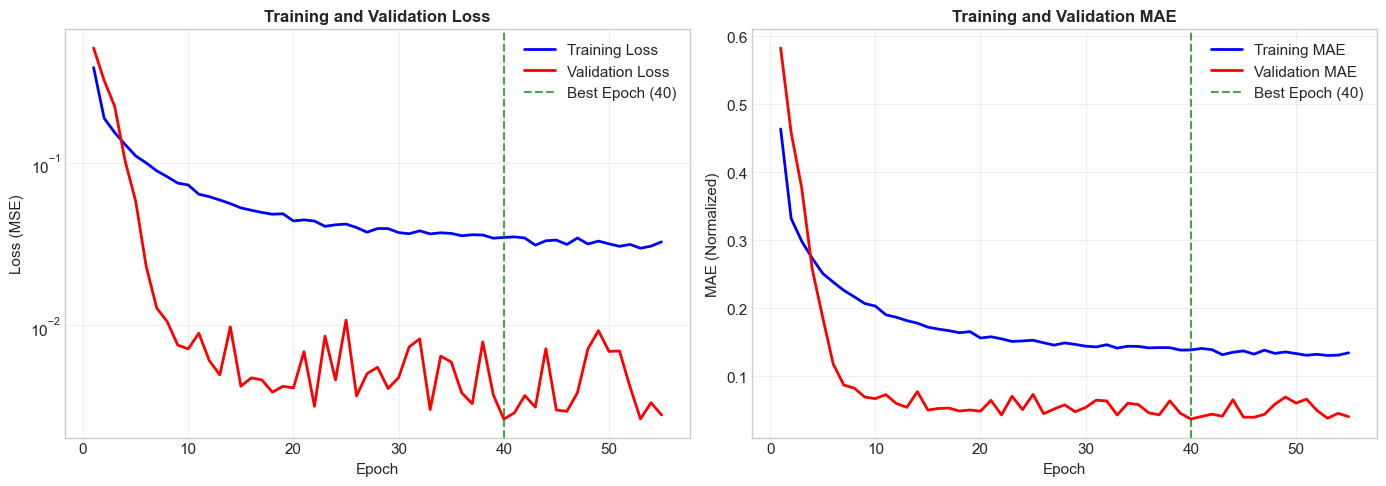

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(result.history['loss']) + 1)

# Loss curves
ax = axes[0]
ax.plot(epochs, result.history['loss'], 'b-', linewidth=2, label='Training Loss')
ax.plot(epochs, result.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
ax.axvline(result.best_epoch, color='green', linestyle='--', alpha=0.7, 
           label=f'Best Epoch ({result.best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # Log scale to see improvement

# MAE curves
ax = axes[1]
ax.plot(epochs, result.history['mae'], 'b-', linewidth=2, label='Training MAE')
ax.plot(epochs, result.history['val_mae'], 'r-', linewidth=2, label='Validation MAE')
ax.axvline(result.best_epoch, color='green', linestyle='--', alpha=0.7,
           label=f'Best Epoch ({result.best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (Normalized)')
ax.set_title('Training and Validation MAE', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# 4. Evaluation

The `Evaluator` class provides comprehensive model evaluation with:

- **Standard metrics**: MSE, MAE, RMSE, R², MAPE
- **Domain-specific metrics**: Max error, percentile errors
- **Visualization**: Prediction plots, residual analysis, error distributions

## 4.1 Test Set Evaluation

In [14]:
from src.m_learning.evaluation import Evaluator, evaluate_model

# Create evaluator with target scaler for denormalization
evaluator = Evaluator(model, target_scaler=dataset.target_stats)

# Evaluate on test set
eval_result = evaluator.evaluate(
    test_data,
    metrics=['mse', 'mae', 'rmse', 'mape', 'r2', 'max_error', 'p95_error'],
)

print(eval_result.summary())

EVALUATION RESULTS
Timestamp: 2026-02-03T11:48:29.337282
Samples: 20000

Metrics:
------------------------------
  mae                 :     0.361759
  mape                : 254301.484375
  max_error           :     2.547546
  mse                 :     0.245066
  p95_error           :     1.025069
  r2                  :       0.9976
  rmse                :     0.495041


## 4.2 Prediction Visualization

Visualizing predictions vs actual values reveals model performance patterns.

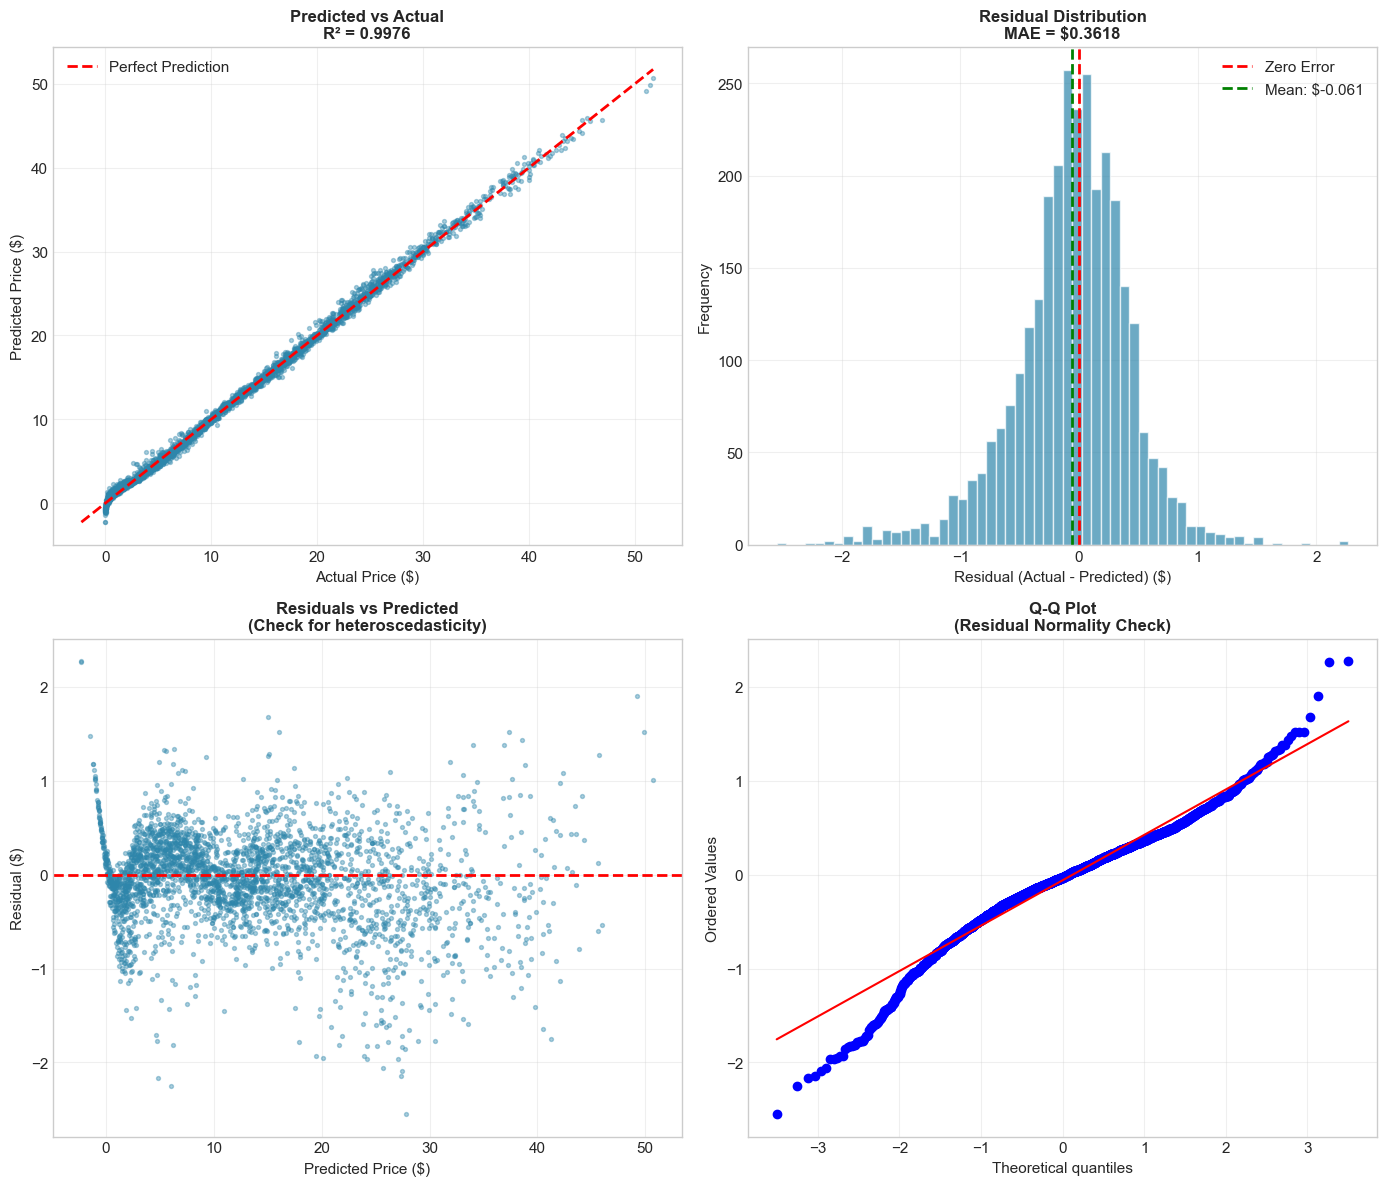

In [15]:
# Comprehensive prediction visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

y_true = eval_result.targets
y_pred = eval_result.predictions
residuals = eval_result.residuals

# 1. Predicted vs Actual (scatter)
ax = axes[0, 0]
ax.scatter(y_true, y_pred, alpha=0.4, s=8, c='#2E86AB')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=11)
ax.set_ylabel('Predicted Price ($)', fontsize=11)
ax.set_title(f'Predicted vs Actual\nR² = {eval_result.metrics["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Residual Distribution
ax = axes[0, 1]
ax.hist(residuals, bins=60, color='#2E86AB', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.axvline(residuals.mean(), color='green', linestyle='--', linewidth=2, 
           label=f'Mean: ${residuals.mean():.3f}')
ax.set_xlabel('Residual (Actual - Predicted) ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Residual Distribution\nMAE = ${eval_result.metrics["mae"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Residuals vs Predicted (heteroscedasticity check)
ax = axes[1, 0]
ax.scatter(y_pred, residuals, alpha=0.4, s=8, c='#2E86AB')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Price ($)', fontsize=11)
ax.set_ylabel('Residual ($)', fontsize=11)
ax.set_title('Residuals vs Predicted\n(Check for heteroscedasticity)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4. Q-Q Plot (normality check)
ax = axes[1, 1]
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot\n(Residual Normality Check)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.3 Error Analysis by Feature

Understanding how errors vary with input features helps identify model weaknesses.

/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_64903/2003265958.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([put_errors, call_errors], labels=['Put', 'Call'])


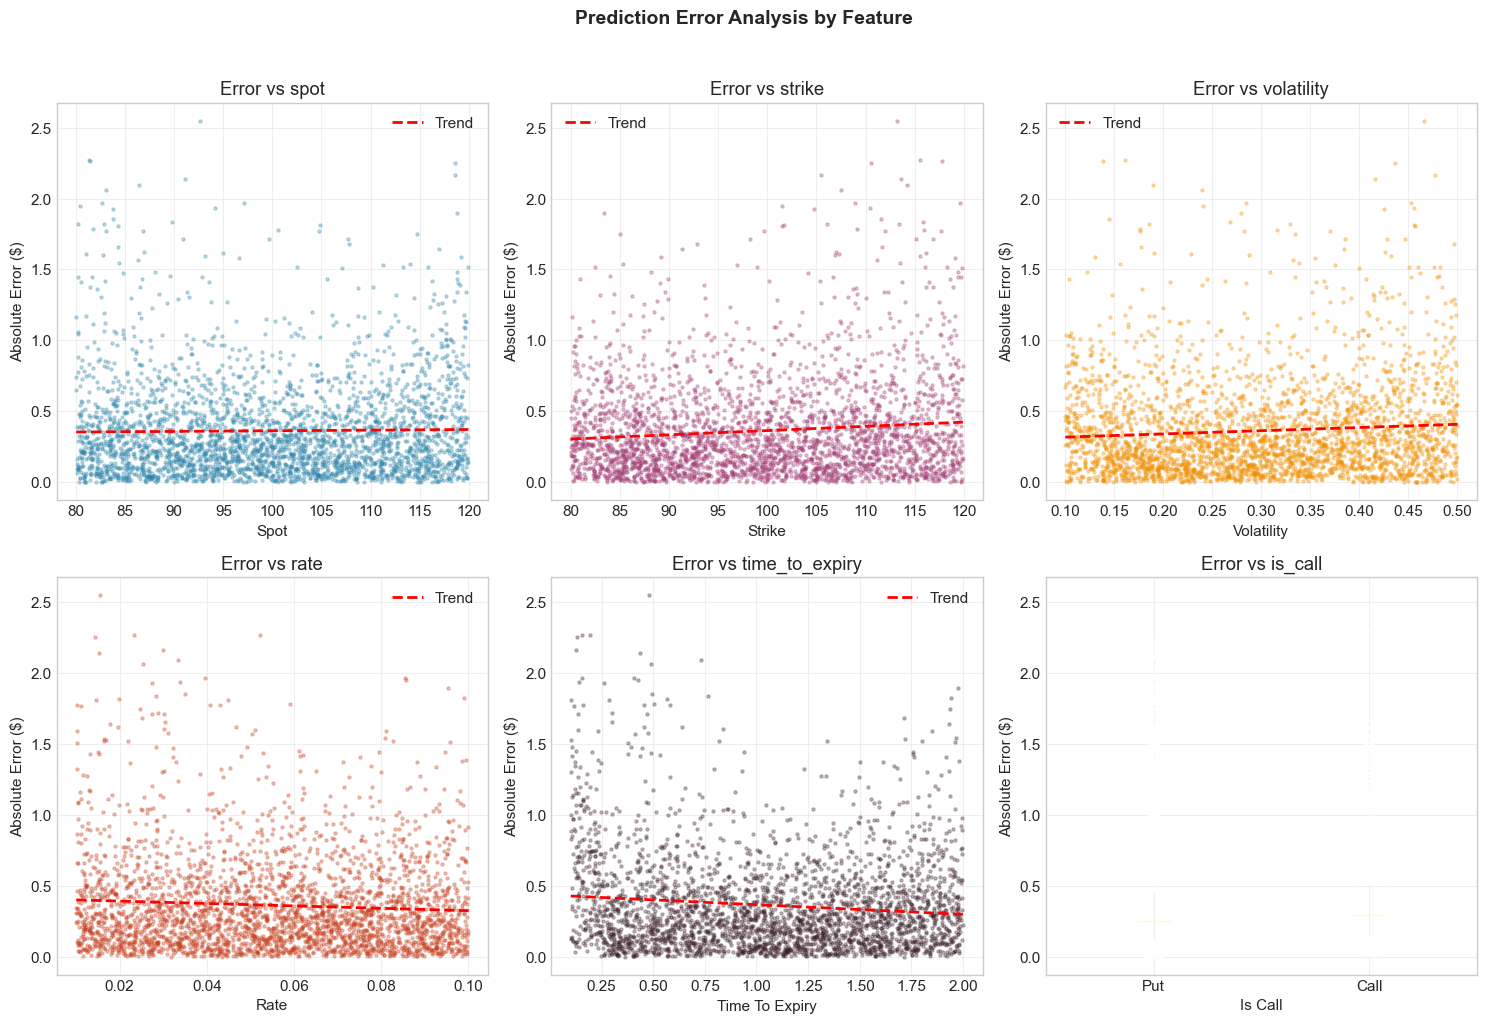

In [16]:
# Denormalize features for visualization
test_features_orig = test_data.feature_stats.denormalize(test_data.features) if test_data.feature_stats else test_data.features
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Prediction Error Analysis by Feature', fontsize=14, fontweight='bold', y=1.02)

feature_names = ['spot', 'strike', 'volatility', 'rate', 'time_to_expiry', 'is_call']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95C623']

for ax, name, color, i in zip(axes.flat, feature_names, colors, range(6)):
    feature_vals = test_features_orig[:, i]
    
    if name == 'is_call':
        # Box plot for categorical
        put_errors = abs_errors[feature_vals < 0.5]
        call_errors = abs_errors[feature_vals >= 0.5]
        ax.boxplot([put_errors, call_errors], labels=['Put', 'Call'])
        ax.set_ylabel('Absolute Error ($)')
    else:
        # Scatter for continuous
        ax.scatter(feature_vals, abs_errors, alpha=0.3, s=5, c=color)
        ax.set_ylabel('Absolute Error ($)')
        
        # Add trend line
        z = np.polyfit(feature_vals, abs_errors, 1)
        p = np.poly1d(z)
        x_sorted = np.sort(feature_vals)
        ax.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, label='Trend')
        ax.legend()
    
    ax.set_xlabel(name.replace('_', ' ').title())
    ax.set_title(f'Error vs {name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# 5. Inference and Deployment

The inference module provides:

- **SavedModel export**: TensorFlow's production format
- **Model artifacts**: Config, metadata, normalization stats
- **Predictor class**: Efficient batch inference

## 5.1 Saving the Model

In [17]:
from src.m_learning.inference import save_model, load_model, Predictor
import tempfile
import os

# Create temporary directory for model
model_dir = tempfile.mkdtemp()
model_path = os.path.join(model_dir, 'fx_vanilla_pricer')

# Save model with all artifacts
save_model(
    model=model,
    path=model_path,
    config=config,
    metadata={
        'description': 'FX Vanilla Option Pricer',
        'version': '1.0.0',
        'author': 'QuantStrata',
        'features': dataset.feature_names,
    },
    feature_stats=dataset.feature_stats,
    target_stats=dataset.target_stats,
    training_history=result.history,
)

# List saved artifacts
print("\nSaved Artifacts:")
for root, dirs, files in os.walk(model_path):
    level = root.replace(model_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        print(f"{subindent}{file} ({size:,} bytes)")

Model saved to: /var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/tmpd2t6lmiw/fx_vanilla_pricer

Saved Artifacts:
fx_vanilla_pricer/
  config.json (629 bytes)
  metadata.json (404 bytes)
  normalization.json (625 bytes)
  model.keras (195,301 bytes)
  training_history.json (5,612 bytes)


## 5.2 Loading the Model

In [18]:
# Load model artifact
artifact = load_model(model_path)

print("Loaded Model Artifact:")
print(f"  Model: {artifact.model.name}")
print(f"  Config: {artifact.config is not None}")
print(f"  Metadata: {artifact.metadata}")
print(f"  Feature stats: {artifact.feature_stats is not None}")
print(f"  Target stats: {artifact.target_stats is not None}")

Model loaded from: /var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/tmpd2t6lmiw/fx_vanilla_pricer
Loaded Model Artifact:
  Model: fx_vanilla_pricer
  Config: True
  Metadata: {'description': 'FX Vanilla Option Pricer', 'version': '1.0.0', 'author': 'QuantStrata', 'features': ['spot', 'strike', 'volatility', 'rate', 'time_to_expiry', 'is_call'], 'saved_at': '2026-02-03T11:48:29.981927', 'tensorflow_version': '2.20.0', 'model_name': 'fx_vanilla_pricer', 'save_format': 'keras', 'trainable_params': 11713, 'total_params': 12161}
  Feature stats: True
  Target stats: True


## 5.3 Making Predictions

The `Predictor` class handles normalization and denormalization automatically.

In [19]:
# Create predictor with scalers
predictor = Predictor(
    model=artifact.model,
    feature_scaler=artifact.feature_stats,
    target_scaler=artifact.target_stats,
)

# Define some sample options to price
sample_options = np.array([
    # [spot, strike, vol, rate, expiry, is_call]
    [100, 100, 0.20, 0.05, 0.5, 1],   # ATM call, 6 months
    [100, 100, 0.20, 0.05, 0.5, 0],   # ATM put, 6 months
    [100, 110, 0.25, 0.05, 1.0, 1],   # OTM call, 1 year
    [100, 90, 0.25, 0.05, 1.0, 0],    # OTM put, 1 year
    [100, 100, 0.30, 0.03, 0.25, 1],  # ATM call, 3 months, high vol
    [100, 105, 0.15, 0.05, 2.0, 1],   # Slightly OTM call, 2 years, low vol
], dtype=np.float32)

# Predict (with automatic normalization/denormalization)
predicted_prices = predictor.predict(
    sample_options,
    normalize=True,   # Normalize input features
    denormalize=True, # Denormalize output prices
)

# Display results
print("\n" + "="*70)
print("OPTION PRICING RESULTS")
print("="*70)
print(f"{'Type':<8} {'Spot':>6} {'Strike':>7} {'Vol':>6} {'Rate':>6} {'Expiry':>7} {'Price':>12}")
print("-"*70)

for opt, price in zip(sample_options, predicted_prices):
    opt_type = 'Call' if opt[5] > 0.5 else 'Put'
    print(f"{opt_type:<8} {opt[0]:>6.0f} {opt[1]:>7.0f} {opt[2]:>6.0%} {opt[3]:>6.1%} {opt[4]:>7.2f}y ${price:>10.2f}")


OPTION PRICING RESULTS
Type       Spot  Strike    Vol   Rate  Expiry        Price
----------------------------------------------------------------------
Call        100     100    20%   5.0%    0.50y $      6.98
Put         100     100    20%   5.0%    0.50y $      4.27
Call        100     110    25%   5.0%    1.00y $      7.94
Put         100      90    25%   5.0%    1.00y $      3.50
Call        100     100    30%   3.0%    0.25y $      6.51
Call        100     105    15%   5.0%    2.00y $     11.12


---

# 6. Advanced Topics

## 6.1 Computing Greeks via Automatic Differentiation

TensorFlow's `GradientTape` allows computing option Greeks as derivatives of price with respect to inputs.

In [ ]:
def compute_greeks(model, features, feature_scaler, target_scaler):
    """
    Compute option Greeks: delta, vega, theta, rho (autodiff) and gamma (finite difference).
    """
    # Normalize features
    features_norm = tf.constant(feature_scaler.normalize(features), dtype=tf.float32)
    
    with tf.GradientTape(persistent=True) as tape1:
        tape1.watch(features_norm)
        price_norm = model(features_norm, training=False)
    grads = tape1.gradient(price_norm, features_norm)
    del tape1

    # Gamma via central finite difference (second-order autodiff returns None here)
    eps = 1e-4
    batch_size = features_norm.shape[0]
    bump = tf.reshape(tf.constant([eps] + [0.0] * 5, dtype=tf.float32), (1, 6))
    bump = tf.tile(bump, [batch_size, 1])
    with tf.GradientTape() as t_plus:
        t_plus.watch(features_norm + bump)
        p_plus = model(features_norm + bump, training=False)
    delta_plus = t_plus.gradient(p_plus, features_norm + bump)[:, 0:1].numpy()
    with tf.GradientTape() as t_minus:
        t_minus.watch(features_norm - bump)
        p_minus = model(features_norm - bump, training=False)
    delta_minus = t_minus.gradient(p_minus, features_norm - bump)[:, 0:1].numpy()
    gamma_norm = (delta_plus - delta_minus) / (2.0 * eps)

    # Convert gradients to original scale
    # d(price)/d(feature) = d(price_norm)/d(feature_norm) * (price_std/feature_std)
    price_std = target_scaler.std[0]
    feat_std = feature_scaler.std
    
    grads_np = grads.numpy()
    
    return {
        'delta': grads_np[:, 0] * price_std / feat_std[0],  # dP/dS
        'vega': grads_np[:, 2] * price_std / feat_std[2] / 100,  # dP/d(vol) per 1% vol
        'theta': -grads_np[:, 4] * price_std / feat_std[4] / 365,  # -dP/dt per day
        'rho': grads_np[:, 3] * price_std / feat_std[3] / 100,  # dP/d(rate) per 1%
        'gamma': gamma_norm.flatten() * price_std / (feat_std[0]**2),  # d²P/dS²
    }

# Compute Greeks for sample options
greeks = compute_greeks(artifact.model, sample_options, artifact.feature_stats, artifact.target_stats)

print("\n" + "="*80)
print("OPTION GREEKS (via Automatic Differentiation)")
print("="*80)
print(f"{'Type':<6} {'Price':>8} {'Delta':>8} {'Gamma':>8} {'Vega':>8} {'Theta':>8} {'Rho':>8}")
print("-"*80)

for i, (opt, price) in enumerate(zip(sample_options, predicted_prices)):
    opt_type = 'Call' if opt[5] > 0.5 else 'Put'
    print(f"{opt_type:<6} ${price:>7.2f} {greeks['delta'][i]:>8.4f} {greeks['gamma'][i]:>8.4f} "
          f"{greeks['vega'][i]:>8.4f} {greeks['theta'][i]:>8.4f} {greeks['rho'][i]:>8.4f}")

TypeError: 'NoneType' object is not subscriptable

## 6.2 Uncertainty Estimation via MC Dropout

Monte Carlo Dropout provides uncertainty estimates by running multiple forward passes with dropout enabled.

In [ ]:
# Predict with uncertainty (requires dropout in model)
mean_price, std_price = predictor.predict_with_uncertainty(
    sample_options,
    n_samples=100,  # Number of forward passes
    normalize=True,
    denormalize=True,
)

print("\n" + "="*60)
print("PRICES WITH UNCERTAINTY (95% CI)")
print("="*60)
print(f"{'Type':<8} {'Mean Price':>12} {'Std':>10} {'95% CI':>20}")
print("-"*60)

for i, opt in enumerate(sample_options):
    opt_type = 'Call' if opt[5] > 0.5 else 'Put'
    ci_low = mean_price[i] - 1.96 * std_price[i]
    ci_high = mean_price[i] + 1.96 * std_price[i]
    print(f"{opt_type:<8} ${mean_price[i]:>10.2f} ${std_price[i]:>8.3f} [{ci_low:>7.2f}, {ci_high:>7.2f}]")

---

# Summary

This tutorial covered the complete QuantStrata ML pipeline:

| Component | Class/Function | Purpose |
|-----------|----------------|--------|
| **Data** | `TFDataset`, `create_pricing_dataset` | Data loading, normalization, splitting |
| **Model** | `MLPPricer`, `create_mlp_pricer` | Neural network architecture |
| **Config** | `TrainingConfig`, `OptimizerConfig` | Training configuration |
| **Training** | `Trainer`, `fit_model` | Model training with callbacks |
| **Evaluation** | `Evaluator`, `evaluate_model` | Metrics and visualization |
| **Inference** | `save_model`, `load_model`, `Predictor` | Deployment and prediction |

## Key Takeaways

1. **TensorFlow-native**: All components use `tf.data.Dataset`, `tf.keras.Model`, and TensorFlow's SavedModel format

2. **Normalization matters**: Always normalize features and targets for stable training

3. **Early stopping**: Prevents overfitting by monitoring validation loss

4. **SavedModel format**: Production-ready serialization with all artifacts

5. **Greeks via autodiff**: TensorFlow's GradientTape enables automatic Greek computation

## Next Steps

- Try different model architectures (`ResidualMLPPricer`)
- Experiment with hyperparameters (learning rate, hidden units)
- Train on real market data
- Explore the GNN-RNN hybrid model for portfolio pricing

See `docs/architecture/component_reference.md` for the full API reference.

In [ ]:
# Cleanup
import shutil
shutil.rmtree(model_dir, ignore_errors=True)

print("\nTutorial complete!")